In [31]:
!pip install docplex cplex openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from docplex.mp.model import Model


In [32]:
# Data Pre-processing

# Load data
file_path = 'Interview small data.xlsx'
df_tutors = pd.read_excel(file_path, sheet_name='Tutor Information')
df_new_students = pd.read_excel(file_path, sheet_name='New Students')
df_existing = pd.read_excel(file_path, sheet_name='Existing Students')

# Calculate Tutor's Current Load (filter active)
active_existing = df_existing[df_existing['active'] == True]
existing_counts = active_existing.groupby('tutorId').size().reset_index(name='current_load')

# Merge DF
df_tutors = df_tutors.merge(existing_counts, on='tutorId', how='left').fillna({'current_load': 0})
df_tutors['current_load'] = df_tutors['current_load'].astype(int)

#Define S & T
students = df_new_students['studentId'].tolist()
tutors = df_tutors['tutorId'].tolist()

#1st and 2nd preference location matrix
########################################################
#toggle high score and low score to control ratio in relation to alpha and beta
#if we keep this constant, then only have to control for alpha and beta values
first_pref_score = 2
second_pref_score = 1
########################################################
pref_scores = {}
for _, s in df_new_students.iterrows():
    for _, t in df_tutors.iterrows():
        score = 0
        if s['tuitionCentre'] == t['preferredCentre1']: score = first_pref_score
        elif s['tuitionCentre'] == t['preferredCentre2']: score = second_pref_score
        pref_scores[(s['studentId'], t['tutorId'])] = score



In [33]:

#Scenario A, Minimize no. Tutors
alpha_a = 100
beta_a = 1
mdl_A = Model(name='Scenario_A_Minimization')

# Variables
x_A = mdl_A.binary_var_matrix(students, tutors, name='assign')
y = mdl_A.binary_var_dict(tutors, name='tutor_used') # 1 if tutor gets any NEW student

# Constraints
for i in students:
    mdl_A.add_constraint(mdl_A.sum(x_A[i, j] for j in tutors) == 1)

for _, s in df_new_students.iterrows():
    if s['tutoringNeed'] == 'Extensive':
        for _, t in df_tutors.iterrows():
            if t['tutoringSkills'] == 'Normal':
                mdl_A.add_constraint(x_A[s['studentId'], t['tutorId']] == 0)

for _, t in df_tutors.iterrows():
    tid, e_j, cap_j = t['tutorId'], t['current_load'], t['maxOverallCapacity']
    new_assign_sum = mdl_A.sum(x_A[i, tid] for i in students)
    # Total capacity constraint
    mdl_A.add_constraint(new_assign_sum + e_j <= cap_j)
    # Tutor active if asssigned: new_assign_sum > 0 implies y[tid] = 1
    mdl_A.add_constraint(new_assign_sum <= (cap_j - e_j) * y[tid])

# Objective + solve
mdl_A.minimize(alph_a * mdl_A.sum(y[j] for j in tutors) - beta_a * mdl_A.sum(pref_scores[i,j] * x_A[i,j] for i,j in pref_scores))
sol_A = mdl_A.solve()


In [34]:

# Scenario B: Balance load (minimize the max workload)

alpha_b = 100
beta_b = 1
mdl_B = Model(name='Scenario_B_Minimax')

# Variables
x_B = mdl_B.binary_var_matrix(students, tutors, name='assign')
L_max = mdl_B.continuous_var(name='peak_workload', lb=0)

# Constraints
for i in students:
    mdl_B.add_constraint(mdl_B.sum(x_B[i, j] for j in tutors) == 1)

for _, s in df_new_students.iterrows():
    if s['tutoringNeed'] == 'Extensive':
        for _, t in df_tutors.iterrows():
            if t['tutoringSkills'] == 'Normal':
                mdl_B.add_constraint(x_B[s['studentId'], t['tutorId']] == 0)

for _, t in df_tutors.iterrows():
    tid, e_j, cap_j = t['tutorId'], t['current_load'], t['maxOverallCapacity']
    total_workload = mdl_B.sum(x_B[i, tid] for i in students) + e_j
    mdl_B.add_constraint(total_workload <= cap_j)
    mdl_B.add_constraint(total_workload <= L_max) # Minimax constraint

# Objective + solve
mdl_B.minimize(alph_b * L_max - beta_b* mdl_B.sum(pref_scores[i,j] * x_B[i,j] for i,j in pref_scores))
sol_B = mdl_B.solve()



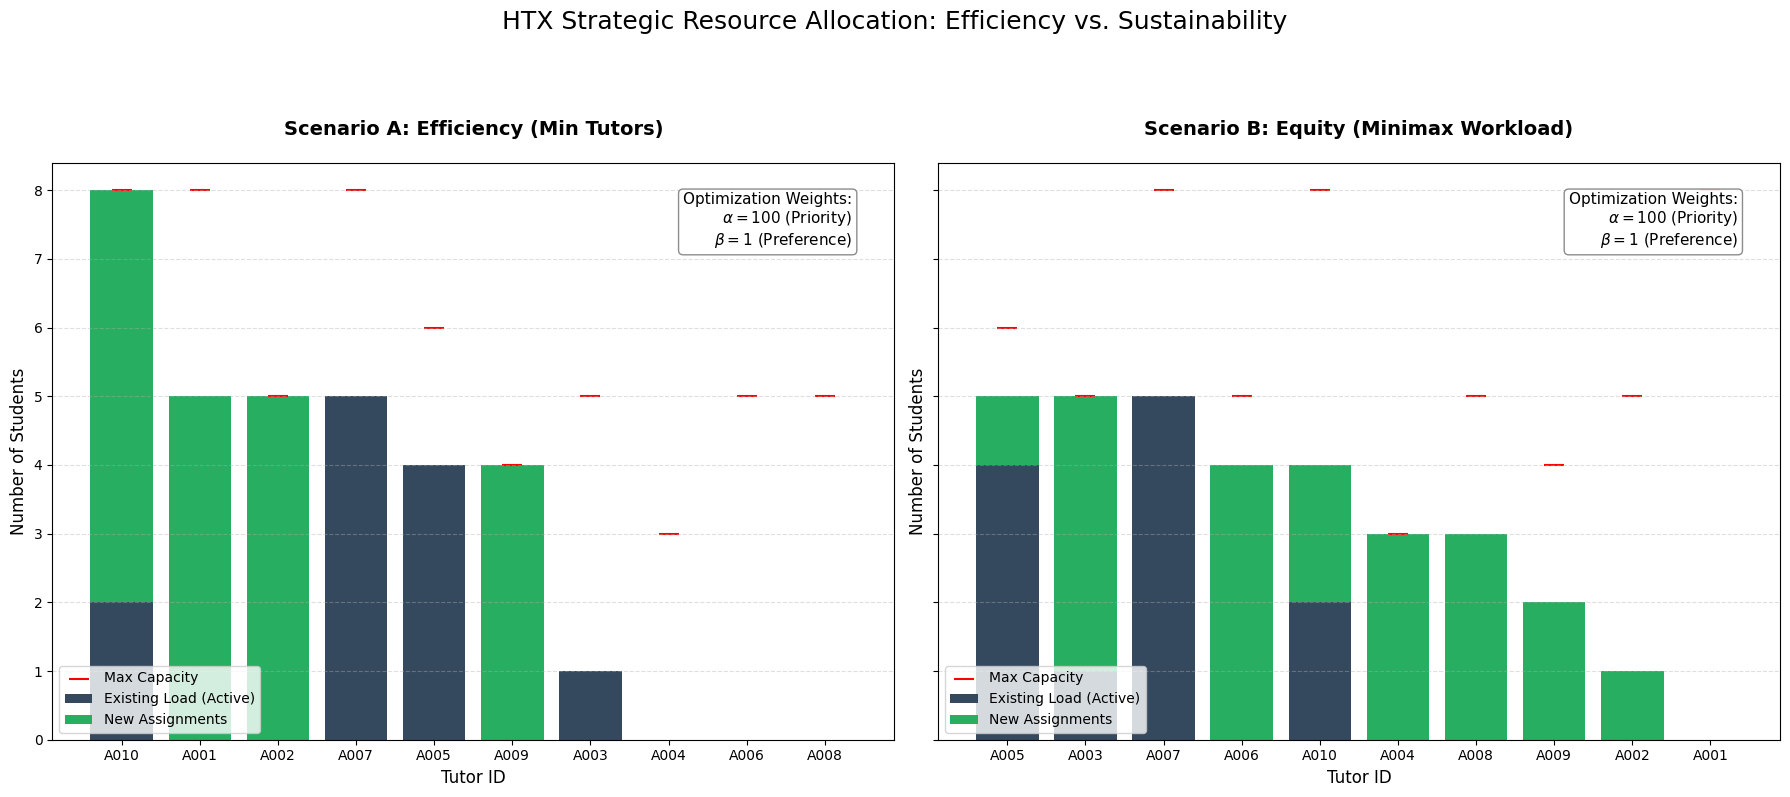

Results
Scenario A (Min Tutors): Used 4 tutors for new students.


In [35]:
# post processing

def get_summary(df_tutors, solution, x_var):
    res = []
    for j in tutors:
        new_count = sum(1 for i in students if solution[x_var[i, j]] > 0.5)
        res.append({'tutorId': j, 'new_students': new_count})
    summary = df_tutors.merge(pd.DataFrame(res), on='tutorId')
    summary['total_load'] = summary['current_load'] + summary['new_students']
    return summary

summary_A = get_summary(df_tutors, sol_A, x_A)
summary_B = get_summary(df_tutors, sol_B, x_B)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# For loop: (Axis, Data, Title, alpha, beta)
plot_configs = zip(
    [ax1, ax2],
    [summary_A, summary_B],
    ["Scenario A: Efficiency (Min Tutors)", "Scenario B: Equity (Minimax Workload)"],
    [alpha_a, alpha_b],
    [beta_a, beta_b]
)

for ax, data, title, alpha_val, beta_val in plot_configs:
    # Sort for visual impact (Highest load first)
    data = data.sort_values('total_load', ascending=False)

    # Plot Stacked Bars
    ax.bar(data['tutorId'], data['current_load'], color='#34495e', label='Existing Load (Active)')
    ax.bar(data['tutorId'], data['new_students'], bottom=data['current_load'], color='#27ae60', label='New Assignments')

    # Capacity Markers
    ax.scatter(data['tutorId'], data['maxOverallCapacity'], color='red', marker='_', s=200, label='Max Capacity')

    # Information textbokx
    param_info = f"Optimization Weights:\n$\\alpha = {alpha_val}$ (Priority)\n$\\beta = {b_val}$ (Preference)"
    ax.text(0.95, 0.95, param_info, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Tutor ID", fontsize=12)
    ax.set_ylabel("Number of Students", fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='lower left', fontsize=10)

# Final Layout Adjustments
plt.suptitle("HTX Strategic Resource Allocation: Efficiency vs. Sustainability", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3. Summary Statistics ---
print("Results")
print("="*40)
print(f"Scenario A (Min Tutors): Used {sum(summary_A['new_students'] > 0)} tutors for new students.")
